In [132]:
# Import your libraries:
import pandas as pd
from sklearn.datasets import load_diabetes

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# Challenge 1 - Explore the Scikit-Learn Datasets

Before starting to work on our own datasets, let's first explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function.

In [15]:
diabetes = load_diabetes()

Let's explore this variable by looking at the different attributes. Do this by looking at the `keys()` of this variable.

In [19]:
print("Keys of the diabetes dataset:")
print(diabetes.keys())

Keys of the diabetes dataset:
dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


The next step is to read the description of the dataset. Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable

In [21]:
# Print the description of the dataset
print("\nDescription of the diabetes dataset:")
print(diabetes.DESCR)


Description of the diabetes dataset:
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each 

What are the variables in this dataset according to the description? List them in the markdown cell below

:Attribute Information:
- age     age in years
- sex
- bmi     body mass index
- bp      average blood pressure
- s1      tc, total serum cholesterol
- s2      ldl, low-density lipoproteins
- s3      hdl, high-density lipoproteins
- s4      tch, total cholesterol / HDL
- s5      ltg, possibly log of serum triglycerides level
- s6      glu, blood sugar level

Now explore the data. Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). In the cell below find the shape of the numpy array contained in the data portion of the diabetes variable.

In [27]:
# Explore the data - Find the shape of the data portion
print("\nShape of the data portion:", diabetes.data.shape)


Shape of the data portion: (442, 10)


# Challenge 2 - Perform Supervised Learning on the Dataset

#### The data has already been split to predictor and response variables. The response variable is in the `target` portion of the variable. 

Given this information, let's apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset. In the cell below, import the linear regression class from sklearn. 

In [432]:
# Perform supervised learning using linear regression
# Split data into predictors and response
X = diabetes.data  # Predictor variables
y = diabetes.target  # Response variable

Initialize the model in the variable `diabetes_model`

In [434]:
# Initialize the linear regression model
diabetes_model = LinearRegression()

In the cell below, fit the model and print the intercept and coefficients of the model. 

In [40]:
# Fit the model to the dataset
diabetes_model.fit(X, y)

# Print the coefficients and intercept
print("\nCoefficients:", diabetes_model.coef_)
print("Intercept:", diabetes_model.intercept_)


Coefficients: [ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]
Intercept: 152.13348416289597


# Bonus Challenge 1 - Conduct a Hypothesis Test on the Model

Once we have generated a linear model, we can test each coefficient using a t-test to see whether the confidence interval for the variable contains zero. We can also perform an overall F test to check whether at least one coefficient is significantly different from zero. 

Refer to the resource in this [link](https://onlinecourses.science.psu.edu/stat501/node/297/) for more details and perform the t-tests for the model above. Additionally, interpret the results and list coefficients are significantly different from zero.


Hint: use the statsmodels package.

Result should look like this:

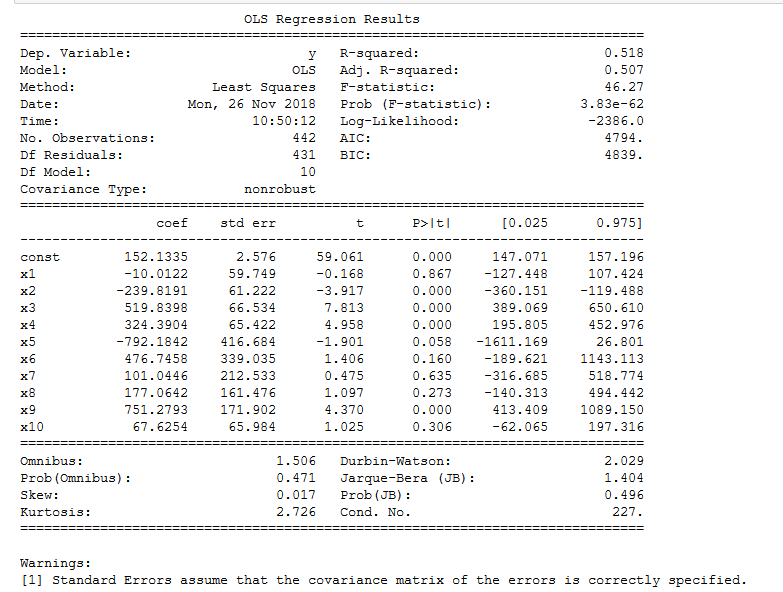

In [44]:
import statsmodels.api as sm

# Add a constant term to the predictor variables for the intercept
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X).fit()

# Summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Wed, 08 Jan 2025   Prob (F-statistic):           3.83e-62
Time:                        21:40:34   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

# Challenge 3 - Peform Supervised Learning on a Pandas Dataframe

Now that we have looked at data that has been formatted for scikit-learn, let's look at data that we will need to format ourselves.

In the next cell, load the `auto-mpg.csv` file included in this folder and assign it to a variable called `auto`.

In [238]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn import datasets
import statsmodels.api as sm

from sklearn.metrics import mean_squared_error, r2_score

In [205]:
# Load the auto-mpg.csv file into a pandas dataframe
auto_df = pd.read_csv('../auto-mpg.csv')

Look at the first 5 rows using the `head()` function:

In [207]:
print("\nFirst few rows of the auto-mpg dataset:")
print(auto_df.head(5))


First few rows of the auto-mpg dataset:
    mpg  cylinders  displacement  horse_power  weight  acceleration  \
0  18.0          8         307.0        130.0    3504          12.0   
1  15.0          8         350.0        165.0    3693          11.5   
2  18.0          8         318.0        150.0    3436          11.0   
3  16.0          8         304.0        150.0    3433          12.0   
4  17.0          8         302.0        140.0    3449          10.5   

   model_year                       car_name  
0          70  \t"chevrolet chevelle malibu"  
1          70          \t"buick skylark 320"  
2          70         \t"plymouth satellite"  
3          70              \t"amc rebel sst"  
4          70                \t"ford torino"  


Evaluate the data to ensure that all numeric columns are correctly detected as such by pandas. If a column is misclassified as object, coerce it to numeric.

In [222]:
print(auto_df.info())

print(auto_df['car_name'])

# Ensure numeric columns are correctly detected
for column in auto_df.columns:
    if auto_df[column].dtype == 'object':
        auto_df[column] = pd.to_numeric(auto_df[column], errors='coerce')

# Check for any missing values after coercion
print("\nData types after coercion:")
print(auto_df.dtypes)
print("\nMissing values per column:")
print(auto_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horse_power   392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   car_name      0 non-null      float64
dtypes: float64(5), int64(3)
memory usage: 25.0 KB
None
0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
393   NaN
394   NaN
395   NaN
396   NaN
397   NaN
Name: car_name, Length: 398, dtype: float64

Data types after coercion:
mpg             float64
cylinders         int64
displacement    float64
horse_power     float64
weight            int64
acceleration    float64
model_year        int64
car_name        float64
dtype: object

Missing values per co

What is the newest model year and the oldest model year?

In [314]:
# Find the newest and oldest model year
newest_year = auto_df['model_year'].max()
oldest_year = auto_df['model_year'].min()
print(f"\nNewest model year: {newest_year}")
print(f"Oldest model year: {oldest_year}")


Newest model year: 82
Oldest model year: 70


Check the dataset for missing values and remove all rows containing at least one missing value.

In [316]:
# Remove rows with missing values
print(auto_df.size)
auto_cleaned = auto_df.dropna()
auto_cleaned.size

2744


2744

In [318]:
print("\nDataset after removing rows with missing values:")
print(auto_cleaned.head())
print(f"Number of rows after cleaning: {auto_cleaned.shape[0]}")


Dataset after removing rows with missing values:
    mpg  cylinders  displacement  horse_power  weight  acceleration  \
0  18.0          8         307.0        130.0    3504          12.0   
1  15.0          8         350.0        165.0    3693          11.5   
2  18.0          8         318.0        150.0    3436          11.0   
3  16.0          8         304.0        150.0    3433          12.0   
4  17.0          8         302.0        140.0    3449          10.5   

   model_year  
0          70  
1          70  
2          70  
3          70  
4          70  
Number of rows after cleaning: 392


Find the frequency table for the `cylinders` column using the `value_counts()` function. How many possible values of cylinders are there?

In [320]:
# Find the frequency table for the cylinders column
cylinder_counts = auto_cleaned['cylinders'].value_counts()
print("\nFrequency table for the cylinders column:")
print(cylinder_counts)

# Count the number of unique cylinder values
unique_cylinders = cylinder_counts.index.nunique()
print(f"\nNumber of possible values of cylinders: {unique_cylinders}")


Frequency table for the cylinders column:
cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

Number of possible values of cylinders: 5


We would like to generate a linear regression model that will predict mpg. To do this, first drop the `car_name` column since it does not contain any quantitative data. Next separate the dataframe to predictor and response variables. Separate those into test and training data with 80% of the data in the training set and the remainder in the test set. 

Assign the predictor and response training data to `X_train` and `y_train` respectively. Similarly, assign the predictor and response test data to `X_test` and `y_test`.

In [324]:
# Drop the car_name column as it does not contain quantitative data
if 'car_name' in auto_cleaned.columns:
    auto_df = auto_cleaned.drop(columns=['car_name'])

# Separate the dataframe into predictor and response variables
X = auto_df.drop(columns=['mpg'])  # Predictor variables
y = auto_df['mpg']  # Response variable

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the datasets
print("\nShapes of the datasets:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


Shapes of the datasets:
X_train: (313, 6), y_train: (313,)
X_test: (79, 6), y_test: (79,)


Now we will the dataset that we processed and peform linear regression on this data to predict the mpg for each vehicle. Initialize the model in the cell below.

In [340]:
# Import necessary libraries
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

print(X_train.head(3))
# Filtrar las filas con valores nulos en 'columna1'
rows_with_nulls = X_train[X_train['horse_power'].isnull()]
print('\nRows with Nulls')
print(rows_with_nulls)

     cylinders  displacement  horse_power  weight  acceleration  model_year
260          6         225.0        110.0    3620          18.7          78
184          4         140.0         92.0    2572          14.9          76
174          6         171.0         97.0    2984          14.5          75

Rows with Nulls
Empty DataFrame
Columns: [cylinders, displacement, horse_power, weight, acceleration, model_year]
Index: []


Next, fit the model in the cell below.

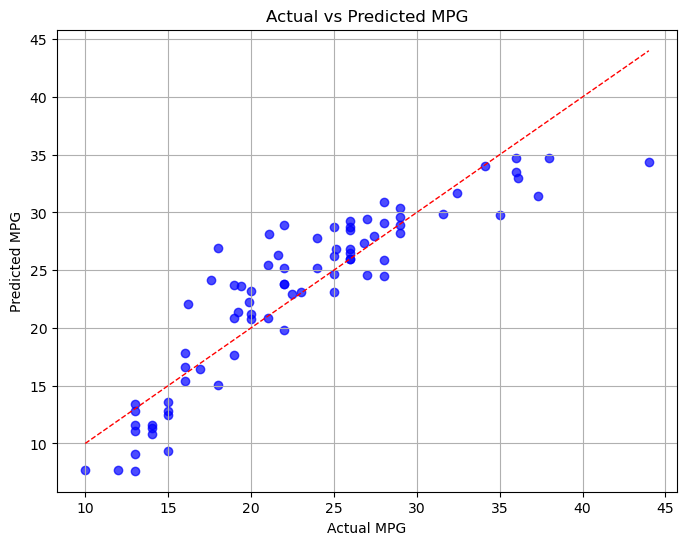

In [438]:
# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = model.predict(X_test)

# Visualize Actual vs Predicted Values
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", linewidth=1)  # Ideal line

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")
plt.grid(True)
plt.show()

# Challenge 4 - Evaluate the Model

the r squared score of a model tells us how much variation is explained by the model. In a typical dataset, most observations differ from the mean. When we create a model, we are trying to generate an equation that will tell us by how much each observation will differ from the mean. Obviously, the vast majority of models are not perfect. They can only predict some of the variation from the mean but not all of it. We attribute the rest of the difference between the actual value and the mean to random error. We would like random error to explain the as little as possible of the variation. This is why the r squared score is an important metric.

In the next cell, compute the r squared score of the model. Do this by first computing the predicted values and assign them to `y_pred`.

In [430]:
# Evaluate the model's performance
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 10.502370329417298
R-squared (R²): 0.7942349075428592


#### Our next step is to evaluate the model using the test data. We would like to ensure that our model is not overfitting the data. This means that our model will not be able to generalize well outside of the training data.

In the cell below, use the model to generate the predicted values for the training data and assign them to `y_test_pred`. Compute the r squared score for the test data by comparing the oberserved `y_train` data and the predicted `y_test_pred`.

In [360]:
# Compute predicted values for the training data
y_train_pred = model.predict(X_train)

# Compute the R-squared score for the training data
r2_train = r2_score(y_train, y_train_pred)

# Compute predicted values for the test data
y_test_pred = model.predict(X_test)

# Compute the R-squared score for the test data
r2_test = r2_score(y_test, y_test_pred)

# Print the R-squared scores
print(f"R-squared Score (Training Data): {r2_train:.4f}")
print(f"R-squared Score (Test Data): {r2_test:.4f}")

R-squared Score (Training Data): 0.8107
R-squared Score (Test Data): 0.7942


# Challenge 5 - Improve the Model Fit

While the most common way to improve the fit of a model is by using regularization, there are other simpler ways to improve model fit. The first is to create a simpler model. The second is to increase the train sample size.

Let us start with the easier option and increase our train sample size to 90% of the data. Create a new test train split and name the new predictors and response variables `X_train09`, `X_test09`, `y_train09`, `y_test09`.

In [376]:
# Create a new train-test split with 90% training data and 10% test data
X_train09, X_test09, y_train09, y_test09 = train_test_split(X, y, train_size=0.9, test_size=0.1, random_state=42)

# Display the shapes of the new datasets
print("Shapes of the new datasets:")
print(f"X_train09: {X_train09.shape}, y_train09: {y_train09.shape}")
print(f"X_test09: {X_test09.shape}, y_test09: {y_test09.shape}")

Shapes of the new datasets:
X_train09: (352, 6), y_train09: (352,)
X_test09: (40, 6), y_test09: (40,)


Initialize a new model. Name this model `auto_model09`. Fit the model to the new sample data.

In [378]:
# Initialize the new model
auto_model09 = LinearRegression()

# Fit the model to the new training data
auto_model09.fit(X_train09, y_train09)

print("auto_model09 has been successfully fitted to the new training data.")

auto_model09 has been successfully fitted to the new training data.


Compute the predicted values and r squared score for our new model and new sample data.

In [380]:
# Compute the predicted values for the new test data
y_test09_pred = auto_model09.predict(X_test09)

# Compute the R-squared score for the new test data
r2_test09 = r2_score(y_test09, y_test09_pred)

# Compute the predicted values for the new training data
y_train09_pred = auto_model09.predict(X_train09)

# Compute the R-squared score for the new training data
r2_train09 = r2_score(y_train09, y_train09_pred)

# Print the R-squared scores
print(f"R-squared Score (Training Data - New Model): {r2_train09:.4f}")
print(f"R-squared Score (Test Data - New Model): {r2_test09:.4f}")

R-squared Score (Training Data - New Model): 0.8048
R-squared Score (Test Data - New Model): 0.8469


Compute the r squared score for the smaller test set. Is there an improvement in the test r squared?

In [384]:
# Compute the R-squared score for the smaller test set
r2_test09 = r2_score(y_test09, y_test09_pred)

# Print the R-squared score for the smaller test set
print(f"R-squared Score (Test Data - Smaller Test Set): {r2_test09:.4f}")

# Compare with the previous test R-squared score
print(f"Previous R-squared Score (Test Data - Larger Test Set): {r2_test:.4f}")

# Check for improvement
if r2_test09 > r2_test:
    print("\nThe R-squared score for the smaller test set shows improvement.")
else:
    print("\nThe R-squared score for the smaller test set does not show improvement.")

R-squared Score (Test Data - Smaller Test Set): 0.8469
Previous R-squared Score (Test Data - Larger Test Set): 0.7942

The R-squared score for the smaller test set shows improvement.


# Bonus Challenge 2 - Backward Elimination 

The main way to produce a simpler linear regression model is to reduce the number of variables used in the model. In scikit-learn, we can do this by using recursive feature elimination. You can read more about RFE [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html).

In the next cell, we will import RFE

In [395]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
auto_model = LinearRegression()

Follow the documentation and initialize an RFE model using the `auto_model` linear regression model. Set `n_features_to_select=3`

In [401]:
# Initialize the RFE model
rfe = RFE(estimator=auto_model, n_features_to_select=3)

rfe

RFE(estimator=LinearRegression(), n_features_to_select=3)

Fit the model and print the ranking

In [415]:
# Fit the RFE model to the training data
rfe.fit(X_train09, y_train09)

# Print the ranking of all features
ranking = rfe.ranking_
feature_ranking = dict(zip(X_train09.columns, ranking))

print("Feature Rankings:")
for feature, rank in feature_ranking.items():
    print(f"{feature}: {rank}")

Feature Rankings:
cylinders: 1
displacement: 3
horse_power: 4
weight: 2
acceleration: 1
model_year: 1


Feature importance is ranked from most important (1) to least important (4). Generate a model with the three most important features. The features correspond to variable names. For example, feature 1 is `cylinders` and feature 2 is `displacement`.

Perform a test-train split on this reduced column data and call the split data `X_train_reduced`, `X_test_reduced`, `y_test_reduced`, `y_train_reduced`. Use an 80% split.

In [422]:
# Get the three most important features
selected_features = X_train09.columns[rfe.support_]
print(f"Selected Features (Top 3): {selected_features}")

# Create a reduced dataset with the top 3 features
X_reduced = X_train09[selected_features]

# Perform the train-test split with an 80% training split
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y_train09, train_size=0.8, test_size=0.2, random_state=42
)

# Display the shapes of the reduced datasets
print("\nShapes of reduced datasets:")
print(f"X_train_reduced: {X_train_reduced.shape}, y_train_reduced: {y_train_reduced.shape}")
print(f"X_test_reduced: {X_test_reduced.shape}, y_test_reduced: {y_test_reduced.shape}")

Selected Features (Top 3): Index(['cylinders', 'acceleration', 'model_year'], dtype='object')

Shapes of reduced datasets:
X_train_reduced: (281, 3), y_train_reduced: (281,)
X_test_reduced: (71, 3), y_test_reduced: (71,)


Generate a new model called `auto_model_reduced` and fit this model. Then proceed to compute the r squared score for the model. Did this cause an improvement in the r squared score?

In [428]:
# Initialize the new model
auto_model_reduced = LinearRegression()

# Fit the model to the reduced training data
auto_model_reduced.fit(X_train_reduced, y_train_reduced)

# Predict values for the test set
y_test_reduced_pred = auto_model_reduced.predict(X_test_reduced)

# Compute the R-squared score for the test set
r2_reduced = r2_score(y_test_reduced, y_test_reduced_pred)

# Print the R-squared score
print(f"R-squared Score (Reduced Model): {r2_reduced:.4f}")

# Compare with the previous test R-squared score
print(f"\nPrevious R-squared Score (Test Data - Original Model): {r2_test:.4f}")
print(f"Previous R-squared Score (Test Data - Larger Training Split): {r2_test09:.4f}")

# Determine improvement
if r2_reduced > r2_test09:
    print("\nThe reduced model caused an improvement in the R-squared score.")
else:
    print("\nThe reduced model did not improve the R-squared score.")

R-squared Score (Reduced Model): 0.6421

Previous R-squared Score (Test Data - Original Model): 0.7942
Previous R-squared Score (Test Data - Larger Training Split): 0.8469

The reduced model did not improve the R-squared score.
